In [7]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import shapely.vectorized as sv

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale

In [8]:
# product = 'IMERG'
# product = 'CMORPH'
# product = 'MSWEP'
# product = 'ERA5'
product = 'GSMaP'
# product = 'CHIRPS'

npix = 2
yy_s,yy_e = 2002, 2023
thresh = 1

In [9]:
# PADOVA
# lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'
# VENETO
lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
# ITALY
# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [10]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..', '..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..', '..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..', '..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.unary_union

In [11]:
if product == 'IMERG':
    filename = 'IMERG_Italy_3h_2001_01_01_2023_12_31.nc'
    L1, dt, time_reso = 10, 3, '3h'
    origin_x_t = [10, 24]
    target_x_t = [0.001, 24]
    tscales = np.array([3,6,9,12,15,18,24,30,36,48])

elif product == 'CMORPH':
    filename = 'CMORPH_Italy_3hr_1998_01_01_2023_12_31.nc'
    L1, dt, time_reso = 25, 3, '3h'
    origin_x_t = [25, 24]
    target_x_t = [0.001, 24]
    tscales = np.array([3,6,9,12,15,18,24,30,36,48])

elif product == 'MSWEP':
    filename = 'MSWEP_Italy_3h_1980_01_01_2023_12_31.nc'
    L1, dt, time_reso = 10, 3, '3h'
    origin_x_t = [10, 24]
    target_x_t = [0.001, 24]
    tscales = np.array([3,6,9,12,15,18,24,30,36,48])

elif product == 'ERA5':
    filename = 'ERA5_Italy_3h_2000_01_01_2023_12_31.nc'
    L1, dt, time_reso = 25, 3, '3h'
    origin_x_t = [25, 24]
    target_x_t = [0.001, 24]
    tscales = np.array([3,6,9,12,15,18,24,30,36,48])

elif product == 'GSMaP':
    filename = 'GSMaP_Italy_3h_2002_01_01_2024_12_31.nc'
    L1, dt, time_reso = 10, 3, '3h'
    origin_x_t = [10, 24]
    target_x_t = [0.001, 24]
    tscales = np.array([3,6,9,12,15,18,24,30,36,48])

elif product == 'CHIRPS':
    filename = 'CHIRPS_Italy_1dy_1981_01_01_2024_06_30.nc'
    L1, dt, time_reso = 5, 24, '1dy'
    origin_x_t = [5, 24]
    target_x_t = [0.001, 24]
    tscales = np.arange(1,11) * 24

else:
    sys.exit('Product not found')

print(f'Product: {product}')
print(f'xscale : {origin_x_t[0]} km to {target_x_t[0]} km')
print(f'tscale : {origin_x_t[1]} hr to {target_x_t[1]} hr')

Product: GSMaP
xscale : 10 km to 0.001 km
tscale : 24 hr to 24 hr


In [12]:
print(f'Product: {product}')

dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite')
dir_input = os.path.join(dir_base,product,time_reso,filename)
DATA = xr.open_dataset(dir_input)
DATA = DATA.sel(time=DATA.time.dt.year.isin(np.arange(yy_s,yy_e+1)))
DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)

lats = DATA['lat'].data
lons = DATA['lon'].data

lon2d, lat2d = np.meshgrid(lons, lats)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)

indices_lat, indices_lon = np.where(mask_study)

Product: GSMaP


In [13]:
# Veneto GSMap beta lower than 1:
# lat_c = lats[23]
# lon_c = lons[19]
# print(f'Lat: {lats[23]}')
# print(f'Lon: {lons[19]}')

# Veneto GSMap beta with bigger value:
# lat_c = lats[26]
# lon_c = lons[40]
# print(f'Lat: {lats[26]}')
# print(f'Lon: {lons[40]}')

# Aleatory
pos = 0
lat_c = lats[pos]
lon_c = lons[pos]
print(f'Lat: {lats[pos]}')
print(f'Lon: {lons[pos]}')

Lat: 43.06
Lon: 9.02


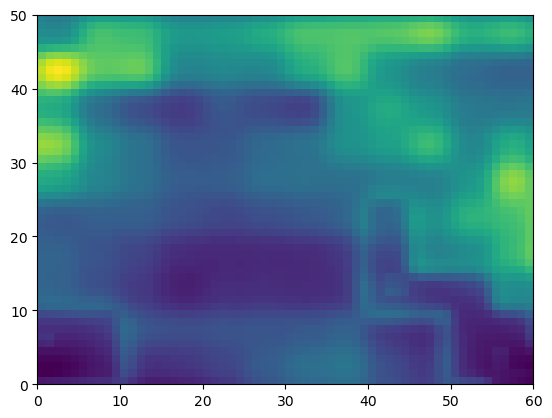

In [14]:
plt.pcolormesh(np.nansum(DATA.PRE.data,axis=0))

In [15]:
PRE_data_T = DATA.transpose('lon', 'lat', 'time')
time_vector_dt = pd.to_datetime(PRE_data_T['PRE']['time'].values)
BOX = xr.DataArray(PRE_data_T['PRE'],  
                        coords={
                            'lon': PRE_data_T['lon'].values, 
                            'lat': PRE_data_T['lat'].values, 
                            'time':time_vector_dt},
                        dims=('lon', 'lat', 'time'))

BOX = DOWN_raw.create_box_v2(BOX, lat_c, lon_c, npix)

In [16]:
pwets, xscales_Z, tscales_Z = DOWN_raw.compute_pwet_xr(BOX, 1, cube1size=npix, dt=3, tmax=48)
xscales_Z2d, tscales_Z2d = np.meshgrid(xscales_Z, tscales_Z)

In [17]:
# WET_MATRIX, xscales_A, tscales_A = DOWN_raw.compute_pwet_xr_v2(BOX, dt, thresh)
# xscales_A2d, tscales_A2d = np.meshgrid(xscales_A, tscales_A)

In [18]:
WET_MATRIX, xscales_A, tscales_A = DOWN_raw.compute_pwet_xr_v3(BOX, tscales, thresh)
xscales_A2d, tscales_A2d = np.meshgrid(xscales_A, tscales_A)

In [19]:
if product == 'CHIRPS':
        WET_MATRIX_inter, t_all, x_all = ART_downscale.interpolate_subdaily_wet_matrix(
                WET_MATRIX,
                tscales_A,
                xscales_A,
                new_tscales=(3,6,12,15),
                kind="cubic")

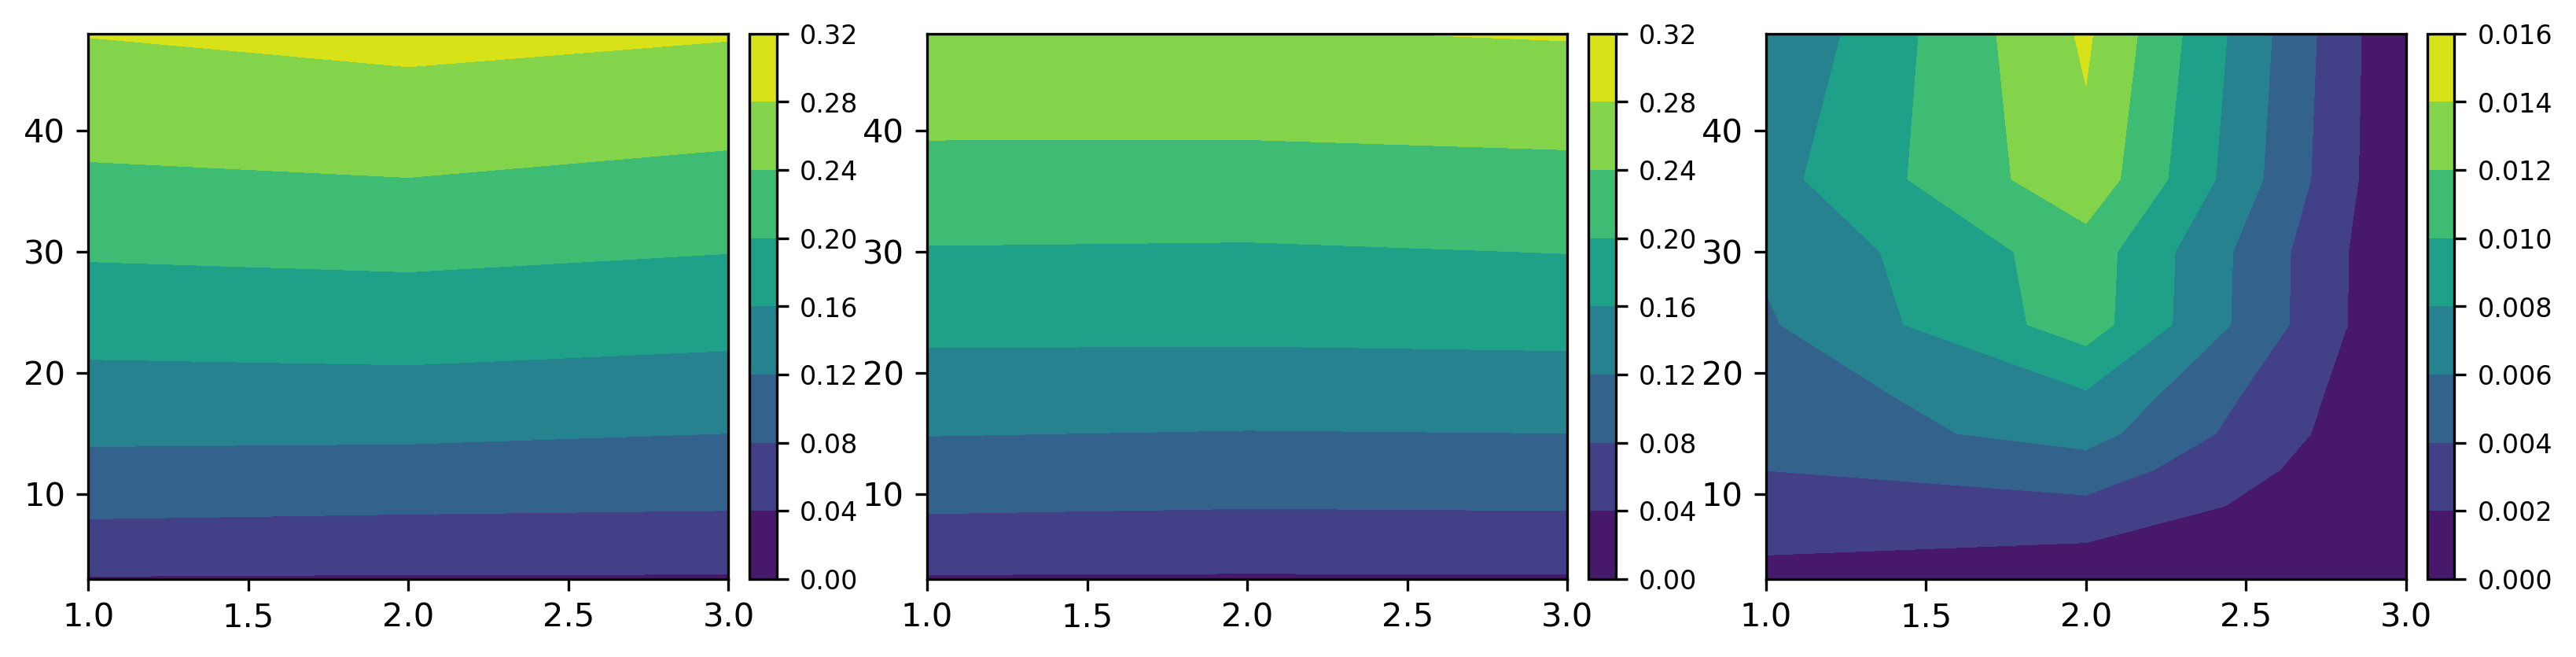

In [20]:
fig = plt.figure(figsize=(13,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0])
a1 = ax1.contourf(xscales_Z2d, tscales_Z2d, pwets)
cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1])
a1 = ax1.contourf(xscales_A2d, tscales_A2d, WET_MATRIX)
cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2])
a1 = ax1.contourf(xscales_A2d, tscales_A2d, pwets - WET_MATRIX)
cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

In [21]:
print(origin_x_t[0],origin_x_t[1])
print(target_x_t[0],target_x_t[1])

10 24
0.001 24


In [22]:
# pwet ZOR, BETA ZOR
beta_A = DOWN_raw.Taylor_beta(pwets, xscales_Z, tscales_Z, L1=L1,
                            origin_x=origin_x_t[0], origin_t=origin_x_t[1],
                            target_x=target_x_t[0], target_t=target_x_t[1],
                            ninterp=1000, plot=True)
beta_A['beta']

0.6775095286743571

In [23]:
# pwet ZOR, BETA ART
WET_MATRIX_EXTRA_A, new_spatial_scale_A = ART_downscale.wet_matrix_extrapolation(WET_MATRIX, xscales_A, tscales_A, L1, npix)

beta_B = DOWN_raw.Taylor_beta(WET_MATRIX, xscales_A, tscales_A, L1=L1,
                            origin_x=origin_x_t[0], origin_t=origin_x_t[1],
                            target_x=target_x_t[0], target_t=target_x_t[1],
                            ninterp=1000, plot=True)
beta_B['beta']

1.0150375380648458

In [24]:
# pwet ART, BETA ZOR
beta_C = ART_downscale.compute_beta(pwets, origin_x_t, target_x_t, xscales_Z, tscales_Z)
beta_C

0.9814782148527076

In [25]:
# pwet ART, BETA ART
WET_MATRIX_EXTRA_A, new_spatial_scale_A = ART_downscale.wet_matrix_extrapolation(WET_MATRIX, xscales_A, tscales_A, L1, npix)

beta_D = ART_downscale.compute_beta(WET_MATRIX_EXTRA_A, origin_x_t, target_x_t, new_spatial_scale_A, tscales_A)
beta_D

1.328485641708565

In [26]:
beta_E = ART_downscale.Taylor_beta_general(pwets,xscales_Z,tscales_Z,L1=L1,
                            origin_x=origin_x_t[0],origin_t=origin_x_t[1],
                            target_x=target_x_t[0],target_t=24,
                            ninterp_t=1000,ninterp_x=200,
                            fit_neighbors=1,plot=True)
beta_E['beta']

1.0259445543552124

In [27]:
WET_MATRIX_EXTRA_A, new_spatial_scale_A = ART_downscale.wet_matrix_extrapolation(WET_MATRIX, xscales_A, tscales_A, L1, npix)

beta_F = ART_downscale.Taylor_beta_general(WET_MATRIX,xscales_A,tscales_A,L1=L1,
                            origin_x=origin_x_t[0],origin_t=origin_x_t[1],
                            target_x=target_x_t[0],target_t=target_x_t[1],
                            ninterp_t=1000,ninterp_x=200,
                            fit_neighbors=2,plot=True)
beta_F['beta']

0.998903217983741

In [34]:
# beta_F = ART_downscale.Taylor_beta_general(WET_MATRIX_inter,x_all,t_all,L1=L1,
#                             origin_x=origin_x_t[0],origin_t=origin_x_t[1],
#                             target_x=target_x_t[0],target_t=target_x_t[1],
#                             ninterp_t=1000,ninterp_x=200,
#                             fit_neighbors=2,plot=True)
# beta_F['beta']

In [30]:
print(f'Product: {product}')
print()
print(f'Beta A: {beta_A['beta']}')
print(f'Beta B: {beta_B['beta']}')
print()
print(f'Beta C: {beta_C}')
print(f'Beta D: {beta_D}')
print()
print(f'Beta E: {beta_E['beta']}')
print(f'Beta F: {beta_F['beta']}')

Product: GSMaP

Beta A: 0.6775095286743571
Beta B: 1.0150375380648458

Beta C: 0.9814782148527076
Beta D: 1.328485641708565

Beta E: 1.0259445543552124
Beta F: 0.998903217983741


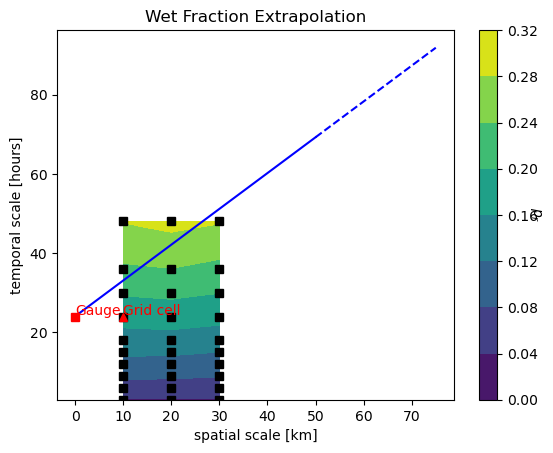

In [31]:
beta_A['contour']

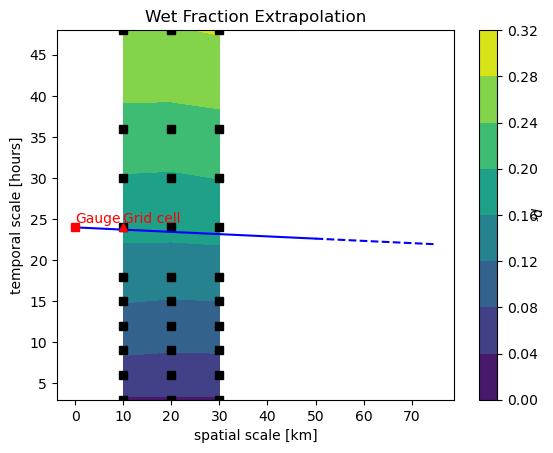

In [32]:
beta_B['contour']

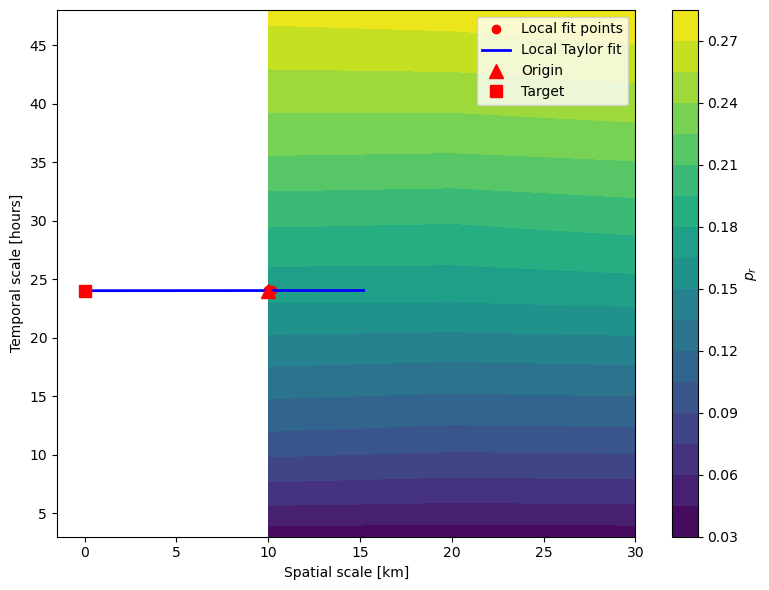

In [33]:
beta_F['contour']

In [ ]:
sys.exit()

SystemExit: 

In [ ]:
from scipy.interpolate import interp1d
from scipy.interpolate import RBFInterpolator

def wet_matrix_extrapolation(WET_MATRIX, spatial_scale, temporal_scale, L1, npix):
    # Create a grid of points for the original data
    original_points = np.array(np.meshgrid(temporal_scale, spatial_scale)).T.reshape(-1, 2)
    wet_fraction_values = WET_MATRIX.ravel()

    # Use RBFInterpolator for cubic extrapolation
    interpolator = RBFInterpolator(original_points, wet_fraction_values, kernel='cubic')

    # New spatial scale with 100 values from 0 to 50 km 
    new_spatial_scale = np.linspace(0, (2*npix+1)*L1, 100)

    # Create new grid for extrapolated data
    new_spatial, new_temporal = np.meshgrid(new_spatial_scale, temporal_scale)

    # Combine the spatial and temporal scales for interpolation
    points_to_interpolate = np.array([new_temporal.ravel(), new_spatial.ravel()]).T

    # Get the interpolated values (including extrapolated values)
    WET_MATRIX_EXTRA = interpolator(points_to_interpolate).reshape(new_temporal.shape)
    
    return WET_MATRIX_EXTRA, new_spatial_scale

def get_isoline_time(pwet_column, t_dense, pw):
    """
    Returns the exact time where the wet fraction equals 'pw'
    using inverse interpolation.

    Parameters
    ----------
    pwet_column : 1D array
        Wet fraction values for one spatial scale.

    t_dense : 1D array
        Interpolated time vector.

    pw : float
        Wet fraction defining the isoline.

    Returns
    -------
    float
        Time corresponding to pw.
        Returns np.nan if pw is outside the range.
    """

    # remove repeated values
    pw_unique, idx = np.unique(pwet_column, return_index=True)
    t_unique = t_dense[idx]

    if len(pw_unique) < 2:
        return np.nan

    if pw < pw_unique.min() or pw > pw_unique.max():
        return np.nan

    f = interp1d(
        pw_unique,
        t_unique,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan
    )

    return float(f(pw))

def Taylor_beta_general(
        pwets,
        xscales,
        tscales,
        *,
        L1=10,
        target_x=0.001,
        target_t=24,
        origin_x=10,
        origin_t=24,
        ninterp_t=1000,
        ninterp_x=200,
        fit_neighbors=3,
        plot=False):

    ############################################################
    # Convert spatial scales
    ############################################################

    xkm = np.asarray(xscales) * L1
    tscales = np.asarray(tscales)

    ############################################################
    # Dense interpolation in time
    ############################################################

    t_dense = np.linspace(tscales.min(),
                          tscales.max(),
                          ninterp_t)

    pw_time = np.zeros((ninterp_t, len(xkm)))

    for j in range(len(xkm)):
        pw_time[:, j] = np.interp(
            t_dense,
            tscales,
            pwets[:, j]
        )

    ############################################################
    # Dense interpolation in space
    ############################################################

    x_dense = np.linspace(
        xkm.min(),
        xkm.max(),
        ninterp_x
    )

    pw_dense = np.zeros((ninterp_t, ninterp_x))

    for i in range(ninterp_t):

        f = interp1d(
            xkm,
            pw_time[i],
            kind="linear",
            fill_value="extrapolate"
        )

        pw_dense[i] = f(x_dense)

    ############################################################
    # Position of origin
    ############################################################

    pos0 = np.argmin(np.abs(x_dense-origin_x))

    left = max(0, pos0-fit_neighbors)
    right = min(ninterp_x, pos0+fit_neighbors+1)

    x_local = x_dense[left:right]

    ############################################################
    # Wet fraction range
    ############################################################

    mypw = np.linspace(
        np.nanmin(pw_dense),
        np.nanmax(pw_dense),
        ninterp_t
    )

    slopes = []
    intercepts = []
    pw_keep = []

    best_x = None
    best_t = None

    ############################################################
    # Loop over isolines
    ############################################################

    for pw in mypw:

        t_local = []

        valid = True

        for xx in x_local:

            ix = np.argmin(np.abs(x_dense-xx))

            tt = get_isoline_time(
                pw_dense[:, ix],
                t_dense,
                pw
            )

            if np.isnan(tt):
                valid = False
                break

            t_local.append(tt)

        if not valid:
            continue

        t_local = np.asarray(t_local)

        coef = np.polyfit(
            t_local,
            x_local,
            1
        )

        slopes.append(coef[0])
        intercepts.append(coef[1])
        pw_keep.append(pw)

    slopes = np.asarray(slopes)
    intercepts = np.asarray(intercepts)
    pw_keep = np.asarray(pw_keep)

    ############################################################
    # Find best isoline
    ############################################################

    t_hat = (target_x-intercepts)/slopes

    idx_best = np.argmin(
        np.abs(
            t_hat-target_t
        )
    )

    ############################################################
    # Recover local points used
    ############################################################

    t_best = []

    for xx in x_local:

        ix = np.argmin(np.abs(x_dense-xx))

        idx = np.argmin(
            np.abs(
                pw_dense[:, ix]-pw_keep[idx_best]
            )
        )

        t_best.append(
            t_dense[idx]
        )

    t_best = np.asarray(t_best)

    ############################################################
    # Origin wet fraction
    ############################################################

    ix = np.argmin(np.abs(x_dense-origin_x))
    it = np.argmin(np.abs(t_dense-origin_t))

    pw_origin = pw_dense[it, ix]

    beta = pw_origin / pw_keep[idx_best]

    ############################################################
    # Output
    ############################################################

    res = {}

    res["beta"] = beta
    res["pwet_origin"] = pw_origin
    res["pwet_target"] = pw_keep[idx_best]
    res["slope"] = slopes[idx_best]
    res["intercept"] = intercepts[idx_best]
    res["t_hat"] = t_hat[idx_best]

    ############################################################
    # Plot
    ############################################################

    if plot:

        fig = plt.figure(figsize=(8,6))

        PS = plt.contourf(
            x_dense,
            t_dense,
            pw_dense,
            levels=20,
            cmap="viridis"
        )

        plt.colorbar(PS,label=r"$p_r$")

        plt.plot(
            x_local,
            t_best,
            'or',
            label="Local fit points"
        )

        xx = np.linspace(
            target_x,
            x_local.max()+5,
            100
        )

        tt = (
            xx-intercepts[idx_best]
        )/slopes[idx_best]

        plt.plot(
            xx,
            tt,
            '-b',
            lw=2,
            label="Local Taylor fit"
        )

        plt.plot(
            origin_x,
            origin_t,
            '^r',
            ms=10,
            label="Origin"
        )

        plt.plot(
            target_x,
            target_t,
            'sr',
            ms=8,
            label="Target"
        )

        plt.xlabel("Spatial scale [km]")
        plt.ylabel("Temporal scale [hours]")

        plt.legend()

        plt.tight_layout()

        plt.close(fig)

        res["contour"] = fig

    return res